## Calculate the sign concordance between RBP Activity Score and SHAP value within same cell line

In [12]:
# Load packages

import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Load necessary data

In [13]:
# Function to get path

from pathlib import Path

def get_path(cell_line: str, path_file: str = "data_path.txt") -> str:
    """
    Reads a base directory path from a text file and returns the full path
    to the cell line data directory.

    Args:
        cell_line (str): The name of the cell line (e.g. "K562" or "HepG2").
        path_file (str): Path to the text file containing the base directory path.

    Returns:
        str: Full path to the data file for the given cell line.
    """
    # Read base path from file
    base_path = Path(path_file).read_text().strip()
    
    # Build full path
    full_path = Path(base_path) / f"{cell_line}_all-data.feather"
    
    return str(full_path)

In [14]:
data_path_HepG2 = get_path("HepG2")
data_HepG2 = pl.read_ipc(data_path_HepG2)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [15]:
data_path_K562 = get_path("K562")
data_K562 = pl.read_ipc(data_path_K562)

Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


In [16]:
# Get RBP activity table 6 events

def plot_rbp_activity_heatmap_6(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05
    filtered_data = (
        data
        .filter(
            (pl.col("Sample Name").str.contains("KD", literal=True))
            & (pl.col("FDR") <= 0.05)
            & (pl.col("DeltaPSI").abs() >= 0.05)
        )    
    )
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    #filtered_data = (
     #   data
      #  .filter(
       #     (data["Sample Name"].str.contains("KD", literal=True))
        #    & (data["FDR"] <= 0.05)
         #   & (data["DeltaPSI"].abs() >= 0.05)
        #)    
   # )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Change this value for number of events

            if (num_pos + num_neg) < 6:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    print("6 events")

    return heatmap_data

In [17]:
# Get RBP activity table 10 events

def plot_rbp_activity_heatmap_10(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05
    filtered_data = (
        data
        .filter(
            (pl.col("Sample Name").str.contains("KD", literal=True))
            & (pl.col("FDR") <= 0.05)
            & (pl.col("DeltaPSI").abs() >= 0.05)
        )    
    )
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Change this value for number of events

            if (num_pos + num_neg) < 10:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    print("10 events")

    return heatmap_data

In [18]:
# Get RBP activity table 20 events

def plot_rbp_activity_heatmap_20(cell_line, data):
    
    print(cell_line)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05
    filtered_data = (
        data
        .filter(
            (pl.col("Sample Name").str.contains("KD", literal=True))
            & (pl.col("FDR") <= 0.05)
            & (pl.col("DeltaPSI").abs() >= 0.05)
        )    
    )
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Change this value for number of events

            if (num_pos + num_neg) < 20:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    print("20 events")

    return heatmap_data

In [19]:
# Load RBP activity data
HepG2_data_6 = plot_rbp_activity_heatmap_6('HepG2', data_HepG2)
K562_data_6 = plot_rbp_activity_heatmap_6('K562', data_K562)

HepG2_data_10 = plot_rbp_activity_heatmap_10('HepG2', data_HepG2)
K562_data_10 = plot_rbp_activity_heatmap_10('K562', data_K562)

HepG2_data_20 = plot_rbp_activity_heatmap_20('HepG2', data_HepG2)
K562_data_20 = plot_rbp_activity_heatmap_20('K562', data_K562)

HepG2
6 events
K562
6 events
HepG2
10 events
K562
10 events
HepG2
20 events
K562
20 events


In [20]:
# Load glossary data
HepG2_glossary = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/HepG2_new_glossary_heatmap.csv")
K562_glossary = pd.read_csv("/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/K562_new_glossary_heatmap.csv")

## Functions to calculate concordance with and without zeros

In [14]:
# Includes zeros and counts them as a match only if the other metric value is zero also

def calculate_sign_concordance(cell_line):
    
    # Manipulate dataframes
    print(cell_line)

    # Manipulate dataframes
    print(cell_line)
    t1 = globals()[f"{cell_line}_data"].copy()
    t2 = globals()[f"{cell_line}_glossary"].T.copy()
    t2.columns = t2.columns + 1  # shift 0-5 → 1-6 to match t1
    
    t1.index.name = None
    t1.columns.name = None
    t2.index.name = None
    t2.columns.name = None
    
    print("t1 columns:", t1.columns.tolist())  # [1, 2, 3, 4, 5, 6]
    print("t2 columns:", t2.columns.tolist())  # [1, 2, 3, 4, 5, 6]
    
    # heatmap_data: rows=RBP, cols=positions  (already correctly oriented)
    # table2: rows=positions, cols=RBP  →  transpose it
    
    # keep only RBPs present in both
    common_proteins = t1.index.intersection(t2.index)
    t1 = t1.loc[common_proteins]
    t2 = t2.loc[common_proteins]
    
    # align on positions
    t1, t2 = t1.align(t2, join="inner", axis=1)
    
    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")
    
    # Calculate % sign concordance: what % of the time are the signs the same?
    
    results = []
    total_match = 0
    total_valid = 0
    
    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]
    
        valid = row1.notna() & row2.notna()
        r1 = row1[valid]
        r2 = row2[valid]
    
        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue
    
        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n        = len(r1)
        pct      = round(matches / n * 100, 2)
    
        total_match += matches
        total_valid += n
    
        results.append({"protein": protein, "concordance": pct})
    
    # outputs
    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)
    
    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))

In [21]:
# Ignore zeros

def calculate_sign_concordance_no_zeros(cell_line, events_cutoff):
    
    # Manipulate dataframes
    print(cell_line)
    t1 = globals()[f"{cell_line}_data_{events_cutoff}"].copy()
    t2 = globals()[f"{cell_line}_glossary"].T.copy()
    t2.columns = t2.columns + 1  # shift 0-5 → 1-6 to match t1
    
    t1.index.name = None
    t1.columns.name = None
    t2.index.name = None
    t2.columns.name = None
    
    print("t1 columns:", t1.columns.tolist())
    print("t2 columns:", t2.columns.tolist())
    
    common_proteins = t1.index.intersection(t2.index)
    t1 = t1.loc[common_proteins]
    t2 = t2.loc[common_proteins]
    
    t1, t2 = t1.align(t2, join="inner", axis=1)
    
    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")
    
    results = []
    total_match = 0
    total_valid = 0
    
    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]
    
        valid = row1.notna() & row2.notna() & (row1 != 0) & (row2 != 0)  # exclude zeros
        r1 = row1[valid]
        r2 = row2[valid]
    
        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue
    
        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n        = len(r1)
        pct      = round(matches / n * 100, 2)
    
        total_match += matches
        total_valid += n
    
        results.append({"protein": protein, "concordance": pct})
    
    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)
    
    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))

In [31]:
K562 = calculate_sign_concordance_no_zeros('K562', 20)

K562
t1 columns: [1, 2, 3, 4, 5, 6]
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 10
Positions being compared: 6

Total sign concordance across all proteins: 53.33%

protein  concordance
    AQR        33.33
 EFTUD2        66.67
  KHSRP       100.00
  RBM15        50.00
  SF3B4        33.33
  SRSF1        50.00
   TIA1       100.00
  U2AF1         0.00
  U2AF2         0.00
  UCHL5       100.00


In [32]:
HepG2 = calculate_sign_concordance_no_zeros('HepG2', 20)

HepG2
t1 columns: [1, 2, 3, 4, 5, 6]
t2 columns: [1, 2, 3, 4, 5, 6]
RBPs in common: 19
Positions being compared: 6

Total sign concordance across all proteins: 32.46%

protein  concordance
    AQR        33.33
 BCLAF1        33.33
  DDX3X         0.00
 EFTUD2         0.00
 HNRNPK        66.67
  KHSRP       100.00
  NCBP2         0.00
   PPIG        66.67
  PRPF8        33.33
    QKI        50.00
 RBFOX2         0.00
  RBM22         0.00
  SF3A3        33.33
  SF3B4        33.33
  SRSF1         0.00
   TIA1       100.00
  TIAL1        50.00
  U2AF1         0.00
  U2AF2        16.67


## Calculate how similar both cell line SHAPs are to each other and how similar the RBP activities are to each other
### To see if the variance in SHAP is similar to the real variance in the data

In [19]:
# Calculates concordance between RBP activity metric across cell lines

In [33]:
def calculate_concordance_activity_metric(df1, df2):
    
    common_proteins = df1.index.intersection(df2.index)
    t1 = df1.loc[common_proteins]
    t2 = df2.loc[common_proteins]
    
    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")
    
    results = []
    
    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]
    
        valid = row1.notna() & row2.notna() & (row1 != 0) & (row2 != 0)
        r1 = row1[valid]
        r2 = row2[valid]
    
        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue
    
        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n       = len(r1)
        pct     = round(matches / n * 100, 2)
    
        results.append({"protein": protein, "concordance": pct})
    
    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)
    
    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))
    
    return concordance_df

In [34]:
activity = calculate_concordance_activity_metric(HepG2_data_20, K562_data_20)

RBPs in common: 8
Positions being compared: 6

Total sign concordance across all proteins: 100.0%

protein  concordance
    AQR        100.0
 EFTUD2        100.0
  KHSRP        100.0
  SF3B4        100.0
  SRSF1        100.0
   TIA1        100.0
  U2AF1        100.0
  U2AF2        100.0


In [35]:
def calculate_concordance_shap_metric(t1, t2):

    t1 = t1.copy().T
    t2 = t2.copy().T

    t1.index.name = None
    t1.columns.name = None
    t2.index.name = None
    t2.columns.name = None

    common_proteins = t1.index.intersection(t2.index)
    t1 = t1.loc[common_proteins]
    t2 = t2.loc[common_proteins]

    t1, t2 = t1.align(t2, join="inner", axis=1)

    print(f"RBPs in common: {len(common_proteins)}")
    print(f"Positions being compared: {t1.shape[1]}")

    results = []

    for protein in common_proteins:
        row1 = t1.loc[protein]
        row2 = t2.loc[protein]

        valid = row1.notna() & row2.notna() & (row1.abs() != 0) & (row2.abs() != 0)
        r1 = row1[valid]
        r2 = row2[valid]

        if len(r1) == 0:
            results.append({"protein": protein, "concordance": np.nan})
            continue

        matches = (np.sign(r1.values) == np.sign(r2.values)).sum()
        n       = len(r1)
        pct     = round(matches / n * 100, 2)

        results.append({"protein": protein, "concordance": pct})

    concordance_df = pd.DataFrame(results)
    total_concordance = round(concordance_df["concordance"].mean(), 2)

    print(f"\nTotal sign concordance across all proteins: {total_concordance}%\n")
    print(concordance_df.to_string(index=False))

    return concordance_df

In [36]:
shap_test = calculate_concordance_shap_metric(HepG2_glossary, K562_glossary)

RBPs in common: 77
Positions being compared: 6

Total sign concordance across all proteins: 73.03%

 protein  concordance
Position       100.00
   AGGF1        66.67
   AKAP1       100.00
     AQR       100.00
   BUD13        83.33
  CSTF2T        83.33
   DDX3X       100.00
   DDX52          NaN
   DDX55        75.00
    DDX6         0.00
   DGCR8        75.00
   DHX30          NaN
  DROSHA        50.00
  EFTUD2        83.33
  EXOSC5          NaN
 FAM120A         0.00
 FASTKD2         0.00
     FTO       100.00
     FUS        66.67
    FXR2        83.33
   GRWD1       100.00
  GTF2F1        80.00
    HLTF         0.00
 HNRNPA1          NaN
  HNRNPC       100.00
  HNRNPK        66.67
  HNRNPL        50.00
  HNRNPM       100.00
  HNRNPU          NaN
HNRNPUL1          NaN
 IGF2BP1       100.00
    ILF3       100.00
   KHSRP        66.67
   LARP4        33.33
   LARP7          NaN
  LIN28B        66.67
   LSM11        66.67
   MATR3       100.00
   NCBP2       100.00
   NOLC1        40.0

## Bar plots comparing RBP Activity Metric across event cutoffs

In [37]:
activity_csv = pd.read_csv('/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/code/activity_v_shap_concordance.csv')

In [38]:
activity_csv

,Cutoff,Value,Cell Line
0,6,48.22,K562
1,6,53.33,HepG2
2,10,50.67,K562
3,10,46.54,HepG2
4,20,53.33,K562
5,20,32.46,HepG2


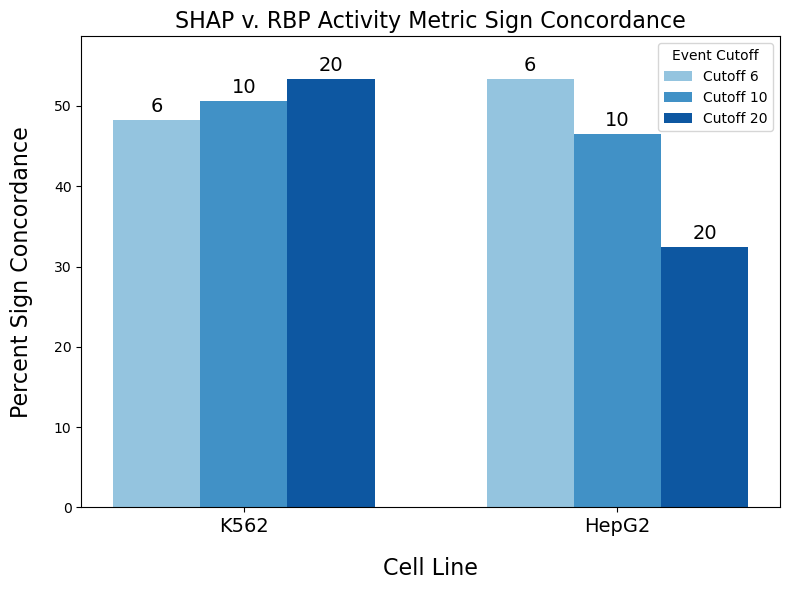

In [39]:
import matplotlib.pyplot as plt
import numpy as np

df = activity_csv


cell_lines = df["Cell Line"].unique()
cutoffs = df["Cutoff"].unique()

x = np.arange(len(cell_lines)) * 1.5  # *2 adds space between groups
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(cutoffs)))

ax.set_ylim(0, df["Value"].max() * 1.1)  # 20% headroom above tallest bar

for i, cutoff in enumerate(cutoffs):
    subset = df[df["Cutoff"] == cutoff]
    values = [subset[subset["Cell Line"] == cl]["Value"].values[0] for cl in cell_lines]
    bars = ax.bar(x + i * width, values, width, label=f"Cutoff {cutoff}", color=colors[i])

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(cutoff), ha='center', va='bottom', fontsize=14)

ax.set_xticks(x + width * (len(cutoffs) - 1) / 2)  # center ticks within each group
ax.set_xticklabels(cell_lines, fontsize = 14)
ax.set_xlabel("Cell Line", fontsize = 16, labelpad=15)
ax.set_ylabel("Percent Sign Concordance", fontsize = 16,labelpad=15)
ax.set_title("SHAP v. RBP Activity Metric Sign Concordance", fontsize = 16)
ax.legend(title="Event Cutoff")

plt.tight_layout()
plt.show()